<div align="center">
<h1>Assignment 2: Build Regression Models</h1>
<h3>Complete Applied Question #10 on page 130 of ISLR Python</h3>
</div>

## 1. Dataset Overview

In [37]:
# Import necessary libraries
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from ISLP import load_data

# Load the Carseats dataset and check the data types of each column
Carseats = load_data('Carseats')
print(Carseats.dtypes)

# Display the first few rows of the Carseats dataset to understand its structure
print(Carseats.head())

Sales           float64
CompPrice         int64
Income            int64
Advertising       int64
Population        int64
Price             int64
ShelveLoc      category
Age               int64
Education         int64
Urban          category
US             category
dtype: object
   Sales  CompPrice  Income  Advertising  Population  Price ShelveLoc  Age  \
0   9.50        138      73           11         276    120       Bad   42   
1  11.22        111      48           16         260     83      Good   65   
2  10.06        113      35           10         269     80    Medium   59   
3   7.40        117     100            4         466     97    Medium   55   
4   4.15        141      64            3         340    128       Bad   38   

   Education Urban   US  
0         17   Yes  Yes  
1         10   Yes  Yes  
2         12   Yes  Yes  
3         14   Yes  Yes  
4         13   Yes   No  


## 2. Complete Applied Question #10
### (a) Fit a multiple regression model to predict Sales using Price, Urban, and US.

In [ ]:
# Model 1: Prepare to fit a multiple regression model to predict Sales using Price, Urban, and US.
y = Carseats['Sales']
X = Carseats[['Price', 'Urban', 'US']]
X = pd.get_dummies(X, columns=['Urban', 'US'], drop_first=True)
X = X.astype(float)
X = sm.add_constant(X)

# Print out the first few rows of the design matrix to verify the dummy variable encoding
print(X.head())

   const  Price  Urban_Yes  US_Yes
0    1.0  120.0        1.0     1.0
1    1.0   83.0        1.0     1.0
2    1.0   80.0        1.0     1.0
3    1.0   97.0        1.0     1.0
4    1.0  128.0        1.0     0.0


In [39]:
# Fit the model and print the summary
model_1 = sm.OLS(y, X)
result_1 = model_1.fit()
print(result_1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           2.39e-23
Time:                        15:33:53   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.0435      0.651     20.036      0.0

### (b) Provide an interpretation of each coefficient in the model

1. **Intercept (const = 13.0435)**: The expected value of the target variable Sales when all predictors are at zero (Urban: not "Yes", US: not "Yes").
2. **Price (-0.0545)**: For each unit increase in Price, and holding other variables constant, Sales decrease by **0.0545** units. This effect is statistically significant (**p < 0.001**).
3. **Urban_Yes (-0.0219)**: For each unit increase in Price, and holding other variables constant, being in an urban area decreases Sales by **0.0219** units. This effect is not statistically significant (**p = 0.936**).
4. **US_Yes (1.2006)**: For each unit increase in Price, and holding other variables constant, being in the US increases Sales by **1.2006** units. This effect is statistically significant (**p < 0.001**).

In Summary, **Price** and **US** are significant predictors of **Sales**, **Urban** does not have a significant effect.

### (c) Write out the model in equation form, being careful to handle the qualitative variables properly
> Sales = β₀ + β₁.Price + β₂.Urban_Yes + β₃.US_Yes + ε

This represents the regression model, where:
- β₀ is the intercept
- β₁ is the coefficient for Price
- β₂ is the coefficient for Urban_Yes
- β₃ is the coefficient for US_Yes
- ε is the error term.

### (d) For which of the predictors can you reject the null hypothesis H0: βj = 0?
We can reject the null hypothesis H₀: βⱼ = 0 for **Price** (p-value = 0.000) and **US_Yes** (p-value = 0.000).

We cannot reject H₀ for **US_Yes** (p-value = 0.936).

So, Price and US_Yes are statistically significant predictors; Urban_Yes is not.

### (e) On the basis of your response to the previous question, fit a smaller model that only uses the predictors for which there is evidence of association with the outcome.

In [40]:
# Model 2: Fit a multiple regression model to predict Sales using Price and US.
X = Carseats[['Price', 'US']]
X = pd.get_dummies(X, columns=['US'], drop_first=True)
X = X.astype(float)
X = sm.add_constant(X)
model_2 = sm.OLS(y, X)
result_2 = model_2.fit()
print(result_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           2.66e-24
Time:                        15:33:53   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.0308      0.631     20.652      0.0

### (f) How well do the models in (a) and (e) fit the data?
Model 2 in (e) is simpler and just as effective as Model 1 in (a). It is preferred because it uses only significant predictors and has slightly better model fit metrics (R-squared is nearly the same, lower value of AIC and BIC indicate better).


### (g) Using the model from (e), obtain 95 % confidence intervals for the coefficient(s).

For Model 2 in (e), the 95% confidence intervals for the coefficients are:
- Intercept: [11.790, 14.271]
- Price: [-0.065, -0.044]
- US_Yes: [0.692, 1.708]

### (h) Is there evidence of outliers or high leverage observations in the model from (e)?

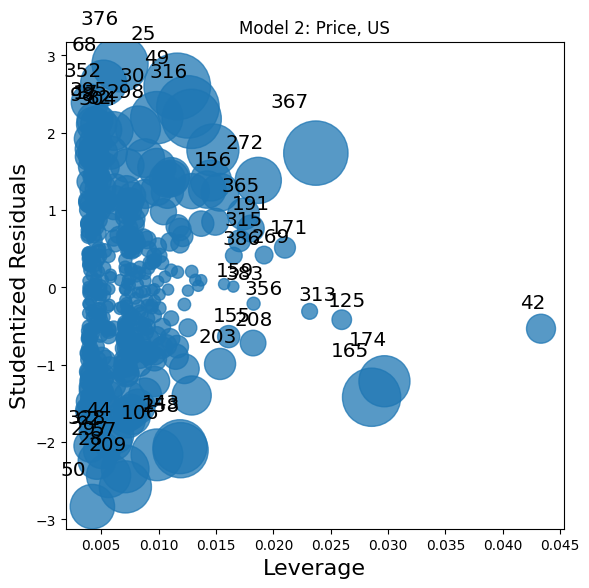

In [41]:
# Plot residuals and leverage statistics to visually and quantitatively assess for outliers or high leverage points
# Only plot for Model 2

influence_2 = result_2.get_influence()
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
sm.graphics.influence_plot(result_2, ax=ax, criterion="cooks")
ax.set_title('Model 2: Price, US')
plt.tight_layout()
plt.show()

From the above plots, there are evidence of outliers and high leverage observations in model from (e).
- **Outliers**: Points like **376** and **50** are far from zero vertically, indicating **large residuals**.
- **High leverage**: Points such as **42** and **174** are farther to the right, indicating they have **high leverage**.